# 03. 데이터 분할 — 단순 계층 분할 vs 그룹 인지 분할

**이 노트북의 목적**

`02`에서 만든 manifest를 읽어 train / val / test를 나눈다. 비율은 **70 / 15 / 15**로 고정하고,
**분할 방식만 다른 두 벌**을 만든다.

| 이름 | 방식 | 근접중복 그룹 |
|---|---|---|
| `split_v1` | `train_test_split(stratify=...)` 2단계 | 고려하지 않음 (갈라질 수 있음) |
| `split_v2` | `StratifiedGroupKFold` 2단계 | 통째로 같은 split에 배치 |

**왜 두 벌을 만드는가**

`02`에서 42개의 근접중복 그룹을 찾았다. 이 중 바이트가 서로 다른 25개 그룹은 MD5로는 안 잡힌다.
같은 사진이 train과 test에 갈라져 들어가면 **모델이 시험 문제를 미리 본 것**이 되어 test 점수가
부풀려진다. 강의 `4_8`에서 스태킹이 `y_test`로 학습해 0.9737을 낸 것과 같은 구조의 데이터 누수다.

문제는 "누수가 있었다"를 주장만 하면 근거가 없다는 점이다. 그래서 **데이터는 완전히 동일하게 두고
분할 방식만 바꾼 두 벌**을 만들어, `06`에서 test 성능 차이를 직접 비교한다. 변수가 하나뿐이라
차이가 나면 그 원인은 분할 방식밖에 없다.

**출력물**: `split_v1.csv`, `split_v2.csv`, `label_map.json`,
`class_weights_v1.csv`, `class_weights_v2.csv`, `norm_stats.json`, `mcnemar_pairs.csv`

## 0. 설정과 manifest 반영

`02`의 manifest에서 `status == "keep"`인 행만 가져온다. 라벨은 `orig_label`이 아니라
**`final_label`**을 쓴다. 파일은 원래 폴더에 그대로 있고, 우리는 CSV가 말하는 라벨을 정답으로 삼는다.

In [1]:
import os, json, time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedGroupKFold

SEED = 42
np.random.seed(SEED)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

OUT = Path("outputs/garbage")
manifest = pd.read_csv(OUT / "metrics" / "manifest.csv")

print(f"manifest 전체 : {len(manifest):,}행")
print(manifest["status"].value_counts().to_string())

manifest 전체 : 15,515행
status
keep    15484
drop       31


In [2]:
df = manifest[manifest["status"] == "keep"].reset_index(drop=True)

classes = sorted(df["final_label"].unique())
label_map = {c: i for i, c in enumerate(classes)}
df["label_idx"] = df["final_label"].map(label_map)

with open(OUT / "metrics" / "label_map.json", "w", encoding="utf-8") as f:
    json.dump(label_map, f, ensure_ascii=False, indent=2)

n_group = df.loc[df["group_id"].str.startswith("nd_"), "group_id"].nunique()
n_grouped_img = int(df["group_id"].str.startswith("nd_").sum())

print(f"학습 대상        : {len(df):,}장 / {len(classes)}클래스")
print(f"근접중복 그룹    : {n_group}개 ({n_grouped_img}장)")
print(f"전체 그룹 수     : {df['group_id'].nunique():,}개 (그룹 없는 이미지는 자기 자신)")
print()
print("클래스 인덱스")
for c, i in label_map.items():
    print(f"  {i:2d}  {c}")

학습 대상        : 15,484장 / 12클래스
근접중복 그룹    : 25개 (51장)
전체 그룹 수     : 15,458개 (그룹 없는 이미지는 자기 자신)

클래스 인덱스
   0  battery
   1  biological
   2  brown-glass
   3  cardboard
   4  clothes
   5  green-glass
   6  metal
   7  paper
   8  plastic
   9  shoes
  10  trash
  11  white-glass


In [3]:
# 라벨 정정이 분포에 미친 영향 확인
cmp = pd.DataFrame({
    "orig":  df["orig_label"].value_counts().reindex(classes),
    "final": df["final_label"].value_counts().reindex(classes),
})
cmp["diff"] = cmp["final"] - cmp["orig"]
print(cmp.to_string())
print(f"\n불균형 비율: {cmp['final'].max() / cmp['final'].min():.2f}배")

             orig  final  diff
battery       945    945     0
biological    985    985     0
brown-glass   607    607     0
cardboard     891    891     0
clothes      5323   5281   -42
green-glass   613    614     1
metal         767    767     0
paper        1050   1049    -1
plastic       862    863     1
shoes        1975   2017    42
trash         696    696     0
white-glass   770    769    -1

불균형 비율: 8.70배


## 1. split_v1 — 단순 계층 분할

`pro1`(헬멧)에서 쓴 것과 같은 2단계 구조다. `stratify`를 걸어 클래스 비율만 유지하고,
근접중복 그룹은 고려하지 않는다. **이것이 정제 이전의 표준 방식**이며 비교 기준선이 된다.

In [4]:
train_v1, temp_v1 = train_test_split(df,
                                     test_size=0.30,
                                     stratify=df["label_idx"],
                                     random_state=SEED,
                                     shuffle=True)

val_v1, test_v1 = train_test_split(temp_v1,
                                   test_size=0.50,
                                   stratify=temp_v1["label_idx"],
                                   random_state=SEED,
                                   shuffle=True)

split_v1 = pd.concat([train_v1.assign(split="train"),
                      val_v1.assign(split="val"),
                      test_v1.assign(split="test")]).reset_index(drop=True)

print(f"train {len(train_v1):,} | val {len(val_v1):,} | test {len(test_v1):,}")
print(f"합계   {len(split_v1):,} (원본 {len(df):,})")
assert len(split_v1) == len(df)
assert split_v1["path"].nunique() == len(split_v1)

train 10,838 | val 2,323 | test 2,323
합계   15,484 (원본 15,484)


## 2. split_v2 — 그룹 인지 분할

`StratifiedGroupKFold`는 클래스 비율을 유지하면서(**Stratified**) 같은 `group_id`를 가진 샘플이
서로 다른 폴드로 흩어지지 않도록(**Group**) 나눈다. 강의 `2_2`에서 배운 `StratifiedKFold`에
그룹 제약을 하나 더 얹은 것이다.

70/15/15를 만들기 위해 2단계로 쓴다.

1. 10-fold로 나눠 3개 폴드를 묶어 temp(30%), 나머지 7개를 train(70%)
2. temp를 다시 2-fold로 나눠 val / test (각 15%)

두 단계 모두 `groups=group_id`를 넘기므로 그룹은 끝까지 쪼개지지 않는다.

In [5]:
groups = df["group_id"].values
y = df["label_idx"].values
X = np.zeros(len(df))

# ── 1단계: 10-fold 중 3개를 temp(30%)로 ──
sgkf1 = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=SEED)
fold_test_idx = [te for _, te in sgkf1.split(X, y, groups)]

temp_idx  = np.concatenate(fold_test_idx[:3])
train_idx = np.concatenate(fold_test_idx[3:])

# ── 2단계: temp를 val / test로 ──
temp_df = df.iloc[temp_idx].reset_index(drop=True)
sgkf2 = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=SEED)
a_idx, b_idx = next(iter(sgkf2.split(np.zeros(len(temp_df)),
                                     temp_df["label_idx"].values,
                                     temp_df["group_id"].values)))

split_v2 = pd.concat([
    df.iloc[train_idx].assign(split="train"),
    temp_df.iloc[a_idx].assign(split="val"),
    temp_df.iloc[b_idx].assign(split="test"),
]).reset_index(drop=True)

counts = split_v2["split"].value_counts()
print(f"train {counts['train']:,} | val {counts['val']:,} | test {counts['test']:,}")
print("비율:", (counts / len(split_v2) * 100).round(1).to_dict())
assert len(split_v2) == len(df)
assert split_v2["path"].nunique() == len(split_v2)

train 10,838 | val 2,323 | test 2,323
비율: {'train': 70.0, 'val': 15.0, 'test': 15.0}


## 3. 누수 검증 — 이 노트북의 핵심 숫자

두 분할에서 **근접중복 그룹이 split 경계를 넘는지** 센다.
`v2`는 0이어야 하고, `v1`에서 나온 숫자가 곧 "그동안 새고 있던 양"이다.

In [6]:
def leak_report(sdf, name):
    g = sdf.groupby("group_id")["split"].nunique()
    spanning = g[g > 1].index
    nd_span = [x for x in spanning if str(x).startswith("nd_")]
    n_img = int(sdf["group_id"].isin(nd_span).sum())

    print(f"[{name}]")
    print(f"  split을 넘나드는 그룹 : {len(nd_span)}개")
    print(f"  해당 이미지          : {n_img}장")

    for gid in nd_span:
        sub = sdf[sdf["group_id"] == gid]
        print(f"    {gid}: " + ", ".join(
            f"{r.filename}({r.split})" for r in sub.itertuples()))
    print()
    return len(nd_span), n_img


n_g1, n_i1 = leak_report(split_v1, "split_v1  단순 계층 분할")
n_g2, n_i2 = leak_report(split_v2, "split_v2  그룹 인지 분할")

assert n_g2 == 0, "v2에서 그룹이 쪼개졌습니다 - StratifiedGroupKFold 설정 확인"
print(f"결론: v1은 {n_g1}개 그룹 {n_i1}장이 갈라져 있고, v2는 0개입니다.")

[split_v1  단순 계층 분할]
  split을 넘나드는 그룹 : 13개
  해당 이미지          : 26장
    nd_000: battery343.jpg(train), battery268.jpg(test)
    nd_001: battery63.jpg(train), battery833.jpg(val)
    nd_007: clothes536.jpg(val), clothes5095.jpg(test)
    nd_010: green-glass228.jpg(train), green-glass433.jpg(val)
    nd_011: green-glass451.jpg(train), green-glass488.jpg(test)
    nd_012: metal745.jpg(train), metal590.jpg(test)
    nd_013: plastic506.jpg(train), plastic467.jpg(test)
    nd_014: shoes1049.jpg(train), shoes1390.jpg(test)
    nd_017: shoes1128.jpg(train), shoes615.jpg(test)
    nd_020: trash238.jpg(train), trash301.jpg(val)
    nd_021: trash559.jpg(train), trash254.jpg(test)
    nd_023: white-glass300.jpg(val), white-glass472.jpg(test)
    nd_024: white-glass688.jpg(train), white-glass674.jpg(test)

[split_v2  그룹 인지 분할]
  split을 넘나드는 그룹 : 0개
  해당 이미지          : 0장

결론: v1은 13개 그룹 26장이 갈라져 있고, v2는 0개입니다.


### 해석

여기서 나온 숫자가 크지 않더라도 의미가 없는 것은 아니다. 갈라진 이미지가 test에 들어갔다면
그 장들은 **거의 확실히 맞는다.** 모델이 train에서 사실상 같은 사진을 봤기 때문이다.

다만 test 2,300여 장 중 몇 장 수준이라면 전체 정확도에 미치는 영향은 0.1%p 안팎일 것이다.
**중요한 것은 크기가 아니라 방향이다.** 누수는 성능을 항상 좋은 쪽으로만 왜곡하므로, 양이 적어도
"우리 숫자는 위쪽으로 편향돼 있지 않다"고 말할 수 있는지가 달라진다. `06`에서 실제 차이를 잰다.

In [7]:
# 클래스 비율이 두 분할 모두 유지됐는지 확인
def ratio_table(sdf):
    piv = sdf.pivot_table(index="final_label", columns="split",
                          values="path", aggfunc="count")
    piv = piv[["train", "val", "test"]]
    piv["total"] = piv.sum(axis=1)
    r = piv[["train", "val", "test"]].div(piv["total"], axis=0) * 100
    r.columns = ["train%", "val%", "test%"]
    return pd.concat([piv, r.round(1)], axis=1)


print("=== split_v1 ===")
print(ratio_table(split_v1).to_string())
print("\n=== split_v2 ===")
print(ratio_table(split_v2).to_string())

=== split_v1 ===
             train  val  test  total  train%  val%  test%
final_label                                              
battery        662  142   141    945    70.1  15.0   14.9
biological     689  148   148    985    69.9  15.0   15.0
brown-glass    425   91    91    607    70.0  15.0   15.0
cardboard      624  134   133    891    70.0  15.0   14.9
clothes       3696  792   793   5281    70.0  15.0   15.0
green-glass    430   92    92    614    70.0  15.0   15.0
metal          537  115   115    767    70.0  15.0   15.0
paper          734  157   158   1049    70.0  15.0   15.1
plastic        604  129   130    863    70.0  14.9   15.1
shoes         1412  303   302   2017    70.0  15.0   15.0
trash          487  105   104    696    70.0  15.1   14.9
white-glass    538  115   116    769    70.0  15.0   15.1

=== split_v2 ===
             train  val  test  total  train%  val%  test%
final_label                                              
battery        662  142   141    945 

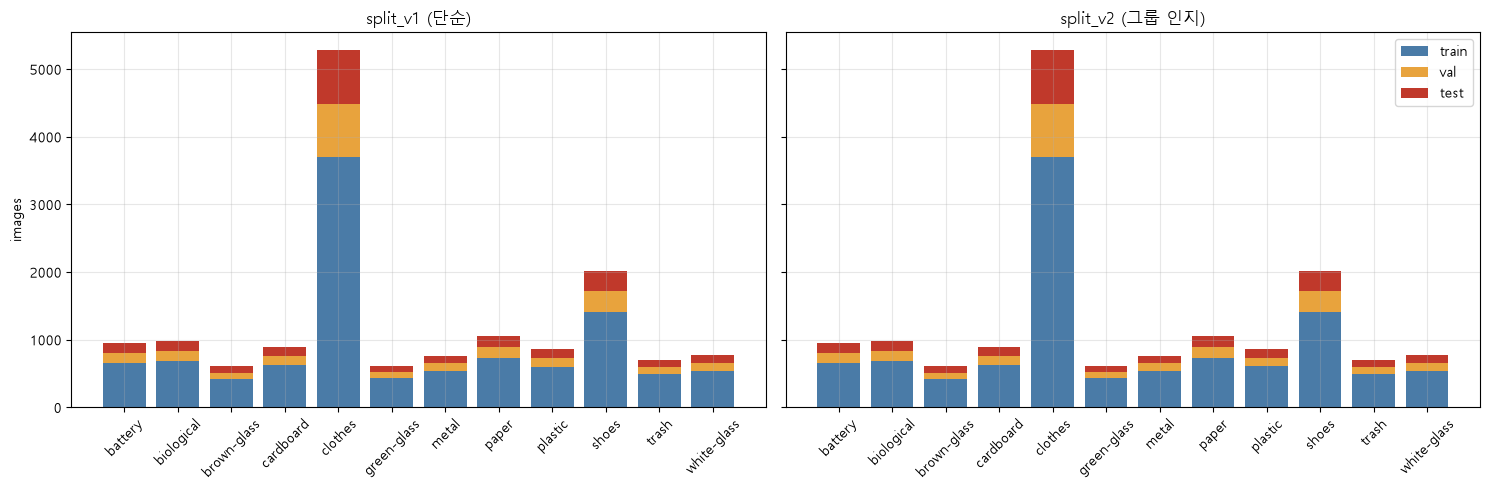

In [8]:
piv1 = ratio_table(split_v1)[["train", "val", "test"]]
piv2 = ratio_table(split_v2)[["train", "val", "test"]]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
colors = {"train": "#4a7ba7", "val": "#e8a33d", "test": "#c0392b"}

for ax, piv, name in zip(axes, [piv1, piv2], ["split_v1 (단순)", "split_v2 (그룹 인지)"]):
    bottom = np.zeros(len(piv))
    for s in ["train", "val", "test"]:
        ax.bar(piv.index, piv[s], bottom=bottom, label=s, color=colors[s])
        bottom += piv[s].values
    ax.set_title(name)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("images")
axes[1].legend()
plt.tight_layout()
plt.savefig(OUT / "figures" / "07_split_compare.png", dpi=150)
plt.show()

## 4. 두 test의 교집합 — `08`의 McNemar 준비

`v1`과 `v2`는 test 구성이 다르다. 그래서 두 결과를 McNemar 검정으로 비교할 수 없다.
McNemar는 **같은 샘플에 대한 두 예측**을 비교하는 대응표본 검정인데, 여기서는 샘플 자체가 다르다.

해결책은 조건을 만족하는 부분집합을 쓰는 것이다.

> 양쪽 **test에 모두 있고**, 양쪽 **train에는 모두 없는** 이미지

이 교집합에서는 두 모델 다 "본 적 없는 데이터"를 예측한 것이므로 공정한 짝 비교가 성립한다.
크기가 너무 작으면 검정력이 부족하므로 여기서 개수를 확인해둔다.

In [9]:
def split_of(sdf):
    return dict(zip(sdf["path"], sdf["split"]))

s1, s2 = split_of(split_v1), split_of(split_v2)

both_test = [p for p in df["path"]
             if s1.get(p) == "test" and s2.get(p) == "test"]

pairs = pd.DataFrame({"path": both_test})
pairs = pairs.merge(df[["path", "filename", "final_label", "label_idx"]], on="path")
pairs.to_csv(OUT / "metrics" / "mcnemar_pairs.csv", index=False, encoding="utf-8")

n1 = int((split_v1["split"] == "test").sum())
n2 = int((split_v2["split"] == "test").sum())
print(f"v1 test {n1:,} | v2 test {n2:,}")
print(f"양쪽 test 교집합 : {len(pairs):,}장 "
      f"(v1 test의 {100 * len(pairs) / n1:.1f}%)")
print()
print("교집합의 클래스 분포")
print(pairs["final_label"].value_counts().reindex(classes).to_string())

if len(pairs) < 300:
    print("\n[주의] 교집합이 작습니다. McNemar 대신 부트스트랩 신뢰구간 비교를 권합니다.")

v1 test 2,323 | v2 test 2,323
양쪽 test 교집합 : 378장 (v1 test의 16.3%)

교집합의 클래스 분포
final_label
battery         29
biological      33
brown-glass     14
cardboard       20
clothes        114
green-glass     10
metal           20
paper           24
plastic         22
shoes           58
trash           15
white-glass     19


## 5. 클래스 가중치

`pro1`에서 쓴 것과 같은 공식이다. 헬멧 노트북에서는 이진이라 `pos_weight` 하나였지만,
12클래스에서는 클래스마다 하나씩 나온다.

$$w_c = \frac{N}{K \cdot n_c}$$

$N$은 train 전체 장수, $K$는 클래스 수, $n_c$는 클래스 $c$의 train 장수다. 적은 클래스일수록
가중치가 커진다. `04`에서 이 값을 `CrossEntropyLoss(weight=...)`와 `WeightedRandomSampler`
두 방식으로 각각 써보고 비교한다.

**train split에서만 계산한다.** val/test의 분포를 보고 가중치를 정하면 그 정보가 학습에 새어 든다.
강의 `02_Scikit-Learn`의 "fit은 train에만" 원칙과 같다.

In [10]:
def class_weights(sdf, tag):
    tr = sdf[sdf["split"] == "train"]
    counts = tr["final_label"].value_counts().reindex(classes)
    w = len(tr) / (len(classes) * counts)

    out = pd.DataFrame({
        "label":        classes,
        "label_idx":    [label_map[c] for c in classes],
        "train_count":  counts.values,
        "class_weight": w.values.round(4),
    }).sort_values("label_idx")

    out.to_csv(OUT / "metrics" / f"class_weights_{tag}.csv",
               index=False, encoding="utf-8")
    print(f"[{tag}] 가중치 범위 {w.min():.3f} ~ {w.max():.3f}")
    return out


cw1 = class_weights(split_v1, "v1")
cw2 = class_weights(split_v2, "v2")
print()
print(cw2.to_string(index=False))

[v1] 가중치 범위 0.244 ~ 2.125
[v2] 가중치 범위 0.244 ~ 2.125

      label  label_idx  train_count  class_weight
    battery          0          662        1.3643
 biological          1          688        1.3127
brown-glass          2          425        2.1251
  cardboard          3          624        1.4474
    clothes          4         3696        0.2444
green-glass          5          430        2.1004
      metal          6          538        1.6787
      paper          7          734        1.2305
    plastic          8          605        1.4928
      shoes          9         1411        0.6401
      trash         10          487        1.8546
white-glass         11          538        1.6787


## 6. 정규화 통계

`04`의 직접 만든 CNN은 **이 데이터셋의 평균·표준편차**를 쓰고, `05`의 전이학습은
**ImageNet 통계**를 쓴다. 사전학습 가중치가 ImageNet 분포에서 학습된 것이라 정규화를 바꾸면
오히려 손해이기 때문이다. `pro1`이 `normalize="simple"` / `"imagenet"`으로 분기한 것과 같은 이유다.

두 split의 train 구성이 조금 다르므로 각각 계산한다. 값이 거의 같게 나오는 것이 정상이다.

In [11]:
SIZE = 128     # 통계 추정용 축소 크기 - 224로 해도 값은 거의 동일

def channel_stats(paths, tag):
    psum, psum_sq, npix = np.zeros(3), np.zeros(3), 0
    t0 = time.time()
    for i, p in enumerate(paths):
        img = cv2.imread(p, cv2.IMREAD_COLOR)
        if img is None:
            continue
        img = cv2.cvtColor(cv2.resize(img, (SIZE, SIZE)), cv2.COLOR_BGR2RGB)
        x = img.astype(np.float64) / 255.0
        psum    += x.sum(axis=(0, 1))
        psum_sq += (x ** 2).sum(axis=(0, 1))
        npix    += x.shape[0] * x.shape[1]
        if (i + 1) % 3000 == 0:
            print(f"  [{tag}] {i + 1:,} / {len(paths):,}")

    mean = psum / npix
    std = np.sqrt(psum_sq / npix - mean ** 2)
    print(f"  [{tag}] 완료 {time.time() - t0:.0f}초")
    return [round(float(v), 4) for v in mean], [round(float(v), 4) for v in std]


m1, s1_ = channel_stats(split_v1.loc[split_v1.split == "train", "path"].tolist(), "v1")
m2, s2_ = channel_stats(split_v2.loc[split_v2.split == "train", "path"].tolist(), "v2")

stats = {
    "v1_mean": m1, "v1_std": s1_,
    "v2_mean": m2, "v2_std": s2_,
    "imagenet_mean": [0.485, 0.456, 0.406],
    "imagenet_std":  [0.229, 0.224, 0.225],
    "computed_on": "train split only",
    "size": SIZE,
}
with open(OUT / "metrics" / "norm_stats.json", "w", encoding="utf-8") as f:
    json.dump(stats, f, ensure_ascii=False, indent=2)

print(f"\nv1 mean {m1}  std {s1_}")
print(f"v2 mean {m2}  std {s2_}")
print(f"imagenet {stats['imagenet_mean']} {stats['imagenet_std']}")

  [v1] 3,000 / 10,838
  [v1] 6,000 / 10,838
  [v1] 9,000 / 10,838
  [v1] 완료 11초
  [v2] 3,000 / 10,838
  [v2] 6,000 / 10,838
  [v2] 9,000 / 10,838
  [v2] 완료 10초

v1 mean [0.6567, 0.6147, 0.584]  std [0.2801, 0.2913, 0.3052]
v2 mean [0.6565, 0.6149, 0.5841]  std [0.2807, 0.2913, 0.3051]
imagenet [0.485, 0.456, 0.406] [0.229, 0.224, 0.225]


## 7. 저장과 최종 검증

`04` 이후의 노트북은 `SPLIT_TAG`("v1" 또는 "v2")만 바꿔서 같은 코드를 두 번 돌린다.
그래서 두 파일의 열 구성을 완전히 동일하게 맞춰둔다.

In [12]:
COLS = ["path", "filename", "final_label", "label_idx", "group_id", "split"]

for sdf, tag in [(split_v1, "v1"), (split_v2, "v2")]:
    out = sdf[COLS].sort_values(["split", "final_label"]).reset_index(drop=True)
    out.to_csv(OUT / "metrics" / f"split_{tag}.csv", index=False, encoding="utf-8")

    sets = {s: set(out.loc[out.split == s, "path"]) for s in ["train", "val", "test"]}
    print(f"[{tag}] {len(out):,}행 저장")
    for a, b in [("train", "val"), ("train", "test"), ("val", "test")]:
        inter = sets[a] & sets[b]
        print(f"   {a:5s} ∩ {b:5s} : {len(inter)}건", "OK" if not inter else "!!! 겹침")

    missing = [p for p in out["path"].sample(300, random_state=SEED)
               if not Path(p).exists()]
    print(f"   표본 300개 중 없는 파일: {len(missing)}개")
    assert not missing

split_summary = {
    "n_images":        int(len(df)),
    "n_classes":       len(classes),
    "ratio":           "70/15/15",
    "v1_method":       "train_test_split(stratify) x2",
    "v2_method":       "StratifiedGroupKFold(10) -> StratifiedGroupKFold(2)",
    "v1_leaked_groups": int(n_g1),
    "v1_leaked_images": int(n_i1),
    "v2_leaked_groups": int(n_g2),
    "mcnemar_pairs":   int(len(pairs)),
}
with open(OUT / "metrics" / "split_summary.json", "w", encoding="utf-8") as f:
    json.dump(split_summary, f, ensure_ascii=False, indent=2)

print()
for k, v in split_summary.items():
    print(f"  {k:18s} {v}")

[v1] 15,484행 저장
   train ∩ val   : 0건 OK
   train ∩ test  : 0건 OK
   val   ∩ test  : 0건 OK
   표본 300개 중 없는 파일: 0개
[v2] 15,484행 저장
   train ∩ val   : 0건 OK
   train ∩ test  : 0건 OK
   val   ∩ test  : 0건 OK
   표본 300개 중 없는 파일: 0개

  n_images           15484
  n_classes          12
  ratio              70/15/15
  v1_method          train_test_split(stratify) x2
  v2_method          StratifiedGroupKFold(10) -> StratifiedGroupKFold(2)
  v1_leaked_groups   13
  v1_leaked_images   26
  v2_leaked_groups   0
  mcnemar_pairs      378


## 정리

| 항목 | 결과 |
|---|---|
| 학습 대상 | 정제 후 이미지 (manifest `status == keep`) |
| 비율 | 70 / 15 / 15, 두 분할 동일 |
| `split_v1` | 계층 분할만. 근접중복 그룹이 갈라짐 |
| `split_v2` | 그룹 인지 분할. 갈라진 그룹 0개 |
| 짝 비교용 교집합 | `mcnemar_pairs.csv` |

**설계상 짚어둘 것**

두 분할은 **같은 데이터**를 쓴다. 정제 여부가 아니라 분할 방식만 다르다. 그래서 `06`에서 성능
차이가 나면 원인이 하나로 특정된다. 변수를 하나만 바꾸는 것이 비교 실험의 기본이다.

`v2`가 `v1`보다 **낮게** 나오는 것이 정상이며, 그것이 이 실험의 성공이다. 누수를 막았으니 부풀려진
분이 빠지는 것이다. 낮아진 숫자가 진짜 일반화 성능이다.

**다음 단계**: 직접 만든 CNN으로 베이스라인을 잡고, 불균형 대응 세 가지를 비교한다.
`SPLIT_TAG`를 바꿔가며 두 번 돌린다.

→ `04_Baseline.ipynb`